# F1 Race Strategy Optimization: FastF1 + Supervised Learning + RL
## Bagian A. Data Audit & Exploratory Analysis

**Data provenance**
- Sumber utama: data timing Formula 1 (F1 Live Timing API) yang diakses lewat library **FastF1** (tidak resmi, tidak berafiliasi dengan F1).
- Dataset turunan dibuat oleh `fastf1_download.py` (`fastf1.get_session(season, round, "R")`, `session.load()`, `session.laps`), kolom `Season`, `Round`, `RaceName`, `RaceLaps` dan data cuaca ditambahkan oleh script.
- Rincian status unduhan per race: `data/download_log.csv`.
- Tanggal unduh: *(isi)*  |  Versi FastF1: lihat sel di bawah.

In [12]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

DATA_PATH = "./data/f1_laps_all_2021_2025.csv"
CLEAN_PATH = "./data/laps_clean.csv"
FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

DRY = ["SOFT", "MEDIUM", "HARD"]
REQUIRE_IS_ACCURATE = True   # IsAccurate = sinkronisasi waktu lap, BUKAN akurasi lap time; lihat sel sensitivitas
WET_RACE_THRESHOLD = 0.05    # race dianggap "wet" jika >= 5% lap memakai INTERMEDIATE/WET (asumsi, bisa diuji)
COMPOUND_COLORS = {"SOFT": "#e10600", "MEDIUM": "#f5c400", "HARD": "#9a9a9a",
                   "INTERMEDIATE": "#3fa34d", "WET": "#1f6fd0"}

try:
    import fastf1
    print("FastF1 version:", fastf1.__version__)
except Exception:
    print("FastF1 tidak terpasang di environment ini (tidak masalah untuk analisis).")

FastF1 version: 3.8.3


In [2]:
df = pd.read_csv(DATA_PATH, dtype={"TrackStatus": str, "DriverNumber": str})


def to_bool(s):
    return s.astype(str).str.strip().str.lower().map({"true": True, "false": False})


for c in ["IsAccurate", "Deleted", "FreshTyre", "IsPersonalBest"]:
    if c in df.columns:
        df[c] = to_bool(df[c])

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125046 entries, 0 to 125045
Data columns (total 42 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Season              125046 non-null  int64  
 1   Round               125046 non-null  int64  
 2   RaceName            125046 non-null  object 
 3   EventDate           125046 non-null  object 
 4   RaceLaps            125046 non-null  float64
 5   Driver              125046 non-null  object 
 6   DriverNumber        125046 non-null  object 
 7   Team                125046 non-null  object 
 8   LapNumber           125046 non-null  float64
 9   Stint               124692 non-null  float64
 10  Compound            124266 non-null  object 
 11  TyreLife            124057 non-null  float64
 12  FreshTyre           125046 non-null  bool   
 13  LapTime             123054 non-null  object 
 14  Sector1Time         122386 non-null  object 
 15  Sector2Time         124844 non-nul

,Season,Round,RaceName,EventDate,RaceLaps,Driver,DriverNumber,Team,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST,Position,TrackStatus,IsAccurate,PitInTime,PitOutTime,Deleted,DeletedReason,LapStartTime,Time,IsPersonalBest,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection,LapTimeSeconds,Sector1TimeSeconds,Sector2TimeSeconds,Sector3TimeSeconds
0,2021,1,Bahrain Grand Prix,2021-03-28,56.0,HAM,44,Mercedes,1.0,1.0,MEDIUM,4.0,False,0 days 00:01:59.538000,NaN,0 days 00:00:54.367000,0 days 00:00:32.463000,233.0,124.0,223.0,258.0,2.0,124,False,NaN,NaN,NaN,NaN,0 days 00:37:09.970000,0 days 00:39:09.686000,False,20.5,28.1,53.7,1014.6,False,1.3,10,119.538,NaN,54.367,32.463
1,2021,1,Bahrain Grand Prix,2021-03-28,56.0,HAM,44,Mercedes,2.0,1.0,MEDIUM,5.0,False,0 days 00:02:22.712000,0 days 00:00:46.763000,0 days 00:01:01.387000,0 days 00:00:34.562000,142.0,172.0,229.0,246.0,2.0,4,False,NaN,NaN,NaN,NaN,0 days 00:39:09.686000,0 days 00:41:32.398000,True,20.5,28.1,53.8,1014.8,False,1.1,13,142.712,46.763,61.387,34.562
2,2021,1,Bahrain Grand Prix,2021-03-28,56.0,HAM,44,Mercedes,3.0,1.0,MEDIUM,6.0,False,NaN,0 days 00:00:43.739000,0 days 00:01:02.116000,0 days 00:00:50.801000,138.0,117.0,167.0,153.0,2.0,41,False,NaN,NaN,NaN,NaN,0 days 00:41:32.398000,0 days 00:44:09.056000,False,20.5,27.9,54.5,1014.8,False,1.0,8,NaN,43.739,62.116,50.801
3,2021,1,Bahrain Grand Prix,2021-03-28,56.0,HAM,44,Mercedes,4.0,1.0,MEDIUM,7.0,False,0 days 00:01:44.932000,0 days 00:00:32.339000,0 days 00:00:41.826000,0 days 00:00:30.767000,237.0,253.0,202.0,290.0,2.0,126,False,NaN,NaN,NaN,NaN,0 days 00:44:09.056000,0 days 00:45:53.988000,True,20.5,27.9,54.7,1014.7,False,0.9,13,104.932,32.339,41.826,30.767
4,2021,1,Bahrain Grand Prix,2021-03-28,56.0,HAM,44,Mercedes,5.0,1.0,MEDIUM,8.0,False,0 days 00:01:45.139000,0 days 00:00:39.813000,0 days 00:00:41.410000,0 days 00:00:23.916000,216.0,261.0,277.0,211.0,2.0,671,False,NaN,NaN,NaN,NaN,0 days 00:45:53.988000,0 days 00:47:39.127000,False,20.5,27.9,54.7,1014.8,False,0.6,35,105.139,39.813,41.410,23.916


### A.1 Ringkasan dataset

In [20]:
print(f"Season  : {df['Season'].nunique()} {sorted(df['Season'].unique())}")
print(f"Race    : {df.groupby(['Season', 'RaceName']).ngroups}")
print(f"Driver  : {df['Driver'].nunique()}")
print(f"Team    : {df['Team'].nunique()}")
print(f"Compound: {sorted(df['Compound'].dropna().unique())}")
print(f"Total baris lap        : {len(df):,}")
print(f"Lap dengan LapTime ada : {df['LapTimeSeconds'].notna().sum():,}")

per_season = df.groupby("Season").agg(
    race=("RaceName", "nunique"), driver=("Driver", "nunique"),
    team=("Team", "nunique"), lap=("LapNumber", "size"))
display(per_season)

# Nama team berbeda antar musim (rebranding). Perlu pemetaan sebelum dipakai sebagai fitur kategori.
display(df.groupby("Season")["Team"].apply(lambda s: sorted(s.dropna().unique())).to_frame("team"))

Season  : 5 [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Race    : 114
Driver  : 35
Team    : 14
Compound: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'UNKNOWN', 'WET']
Total baris lap        : 125,046
Lap dengan LapTime ada : 123,054


,race,driver,team,lap
Season,,,,
2021,22,21,10,23756
2022,22,22,10,23577
2023,22,22,10,24420
2024,24,24,10,26604
2025,24,21,10,26689


,team
Season,
2021,"[Alfa Romeo Racing, AlphaTauri, Alpine, Aston ..."
2022,"[Alfa Romeo, AlphaTauri, Alpine, Aston Martin,..."
2023,"[Alfa Romeo, AlphaTauri, Alpine, Aston Martin,..."
2024,"[Alpine, Aston Martin, Ferrari, Haas F1 Team, ..."
2025,"[Alpine, Aston Martin, Ferrari, Haas F1 Team, ..."


### A.2 Konversi waktu, flag anomali, dan definisi *clean racing lap*

`LapTimeSeconds` dan `Sector*Seconds` sudah dikonversi dari `timedelta` ke detik oleh script unduhan.
Notebook ini **menandai** (flag) setiap kondisi bermasalah terlebih dahulu, baru kemudian memutuskan treatment-nya.

In [4]:
# --- Flag dasar ---
df["RaceLaps"] = df.groupby(["Season", "RaceName"])["LapNumber"].transform("max") \
    if "RaceLaps" not in df.columns else df["RaceLaps"]

df["is_missing_laptime"] = df["LapTimeSeconds"].isna() | (df["LapTimeSeconds"] <= 0)
df["is_inaccurate"] = ~df["IsAccurate"].fillna(False).astype(bool) if "IsAccurate" in df.columns else False
df["is_deleted"] = df["Deleted"].fillna(False).astype(bool) if "Deleted" in df.columns else False
if "Deleted" not in df.columns or df["Deleted"].isna().all():
    print("CATATAN: kolom Deleted kosong 100% (race control messages tidak dimuat saat download). "
          "Deteksi lap deleted TIDAK tersedia; ini dicatat sebagai limitation.")
df["is_pit_lap"] = df["PitInTime"].notna() | df["PitOutTime"].notna()
df["is_green"] = df["TrackStatus"] == "1"
df["is_sc_vsc_red"] = df["TrackStatus"].fillna("").str.contains("[4567]")   # 4=SC, 5=red, 6/7=VSC

# --- Outlier pace: rasio terhadap median race (lap hijau, dry, bukan pit) ---
base = (~df["is_missing_laptime"]) & (~df["is_pit_lap"]) & df["is_green"] & df["Compound"].isin(DRY)
ref = (df[base].groupby(["Season", "RaceName"])["LapTimeSeconds"].median().rename("race_median").reset_index())
df = df.merge(ref, on=["Season", "RaceName"], how="left")
df["pace_ratio"] = df["LapTimeSeconds"] / df["race_median"]
df["pace_delta"] = df["LapTimeSeconds"] - df["race_median"]      # detik relatif terhadap median race
df["is_outlier"] = (df["pace_ratio"] > 1.15) | (df["pace_ratio"] < 0.90)
df["laps_remaining"] = df["RaceLaps"] - df["LapNumber"]

# --- Wet race: proporsi lap INTERMEDIATE/WET per race ---
wet = (df.groupby(["Season", "RaceName"])["Compound"]
         .apply(lambda s: s.isin(["INTERMEDIATE", "WET"]).mean()).rename("wet_share").reset_index())
df = df.merge(wet, on=["Season", "RaceName"], how="left")
df["is_wet_race"] = df["wet_share"] >= WET_RACE_THRESHOLD
print(f"Race dengan lap INTERMEDIATE/WET: {(wet['wet_share'] > 0).sum()} | "
      f"dianggap wet race (>= {WET_RACE_THRESHOLD:.0%}): {wet[wet['wet_share'] >= WET_RACE_THRESHOLD].shape[0]}")
display(wet[wet["wet_share"] > 0].sort_values("wet_share", ascending=False).round(3))

flags = ["is_missing_laptime", "is_inaccurate", "is_deleted", "is_pit_lap",
         "is_sc_vsc_red", "is_outlier"]
display(pd.DataFrame({"jumlah": df[flags].sum(), "persen": (df[flags].mean() * 100).round(2)}))

CATATAN: kolom Deleted kosong 100% (race control messages tidak dimuat saat download). Deteksi lap deleted TIDAK tersedia; ini dicatat sebagai limitation.
Race dengan lap INTERMEDIATE/WET: 16 | dianggap wet race (>= 5%): 16


,Season,RaceName,wet_share
35,2022,Japanese Grand Prix,1.000
88,2024,São Paulo Grand Prix,1.000
20,2021,Turkish Grand Prix,0.999
91,2025,Australian Grand Prix,0.809
96,2025,British Grand Prix,0.737
73,2024,Canadian Grand Prix,0.665
40,2022,Singapore Grand Prix,0.622
7,2021,Emilia Romagna Grand Prix,0.442
38,2022,Monaco Grand Prix,0.338
59,2023,Monaco Grand Prix,0.293


,jumlah,persen
is_missing_laptime,1992,1.59
is_inaccurate,16789,13.43
is_deleted,0,0.00
is_pit_lap,8318,6.65
is_sc_vsc_red,8801,7.04
is_outlier,10743,8.59


In [5]:
# --- Funnel: dari seluruh lap ke clean racing lap ---
steps = [
    ("Total lap", pd.Series(True, index=df.index)),
    ("LapTime valid (> 0)", ~df["is_missing_laptime"]),
    ("IsAccurate = True" if REQUIRE_IS_ACCURATE else "IsAccurate (tidak dipakai)",
     ~df["is_inaccurate"] if REQUIRE_IS_ACCURATE else pd.Series(True, index=df.index)),
    ("Bukan lap deleted (kolom kosong, tidak berefek)", ~df["is_deleted"]),
    ("Bukan pit in/out lap", ~df["is_pit_lap"]),
    ("Green flag (TrackStatus = '1')", df["is_green"]),
    ("Compound dry (S/M/H)", df["Compound"].isin(DRY)),
    ("Bukan lap 1 (standing start)", df["LapNumber"] > 1),
    ("TyreLife tersedia", df["TyreLife"].notna()),
    ("Bukan outlier pace", ~df["is_outlier"]),
]
m = pd.Series(True, index=df.index)
rows = []
for name, cond in steps:
    cond = cond.fillna(False).astype(bool)
    m &= cond
    rows.append((name, int(m.sum()), int((~cond).sum())))

funnel = pd.DataFrame(rows, columns=["Filter", "Sisa lap (kumulatif)", "Dibuang oleh filter ini saja"])
funnel["% sisa dari total"] = (funnel["Sisa lap (kumulatif)"] / len(df) * 100).round(1)
display(funnel)
print("Catatan: filter saling tumpang tindih (mis. semua in/out lap sudah IsAccurate=False), "
      "jadi kolom kumulatif bergantung urutan; gunakan kolom 'filter ini saja' untuk membaca dampak tiap filter.")

clean = df[m].copy()
clean.to_csv(CLEAN_PATH, index=False)
print(f"Clean racing lap: {len(clean):,} -> {CLEAN_PATH}")

,Filter,Sisa lap (kumulatif),Dibuang oleh filter ini saja,% sisa dari total
0,Total lap,125046,0,100.0
1,LapTime valid (> 0),123054,1992,98.4
2,IsAccurate = True,108257,16789,86.6
3,"Bukan lap deleted (kolom kosong, tidak berefek)",108257,0,86.6
4,Bukan pit in/out lap,108257,8318,86.6
5,Green flag (TrackStatus = '1'),104946,12949,83.9
6,Compound dry (S/M/H),98594,9008,78.8
7,Bukan lap 1 (standing start),98594,2263,78.8
8,TyreLife tersedia,98435,989,78.7
9,Bukan outlier pace,98280,10743,78.6


Catatan: filter saling tumpang tindih (mis. semua in/out lap sudah IsAccurate=False), jadi kolom kumulatif bergantung urutan; gunakan kolom 'filter ini saja' untuk membaca dampak tiap filter.
Clean racing lap: 98,280 -> ./data/laps_clean.csv


In [6]:
# Sensitivitas IsAccurate: apakah lap yang lolos semua filter lain tetapi IsAccurate=False berbeda pace-nya?
others = (~df["is_missing_laptime"] & ~df["is_deleted"] & ~df["is_pit_lap"] & df["is_green"]
          & df["Compound"].isin(DRY) & (df["LapNumber"] > 1) & df["TyreLife"].notna() & ~df["is_outlier"])
acc = ~df["is_inaccurate"]
groups = {"IsAccurate = True": others & acc, "IsAccurate = False (lolos filter lain)": others & ~acc}
sens = pd.DataFrame({k: df.loc[v, "pace_delta"].agg(["count", "mean", "median", "std"]) for k, v in groups.items()}).T
display(sens.round(3))
print("Jika mean/median/std kedua kelompok mirip, IsAccurate tidak wajib dipakai; "
      "jika lap 'False' sangat menyimpang, pertahankan sebagai filter. Laporkan hasilnya.")

,count,mean,median,std
IsAccurate = True,98280.0,0.043,-0.018,1.387
IsAccurate = False (lolos filter lain),37.0,-1.357,-1.563,1.156


Jika mean/median/std kedua kelompok mirip, IsAccurate tidak wajib dipakai; jika lap 'False' sangat menyimpang, pertahankan sebagai filter. Laporkan hasilnya.


**Treatment yang dipakai (dokumentasikan alasannya di laporan)**

| Kondisi | Treatment | Alasan |
|---|---|---|
| LapTime NaT / kosong | Dikeluarkan dari data latih | Target tidak ada; tidak diimputasi agar tidak menciptakan label palsu |
| `IsAccurate = False` | Dikeluarkan (konservatif); dampaknya diuji di sel sensitivitas | Menurut dokumentasi FastF1, flag ini menandai sinkronisasi waktu mulai/akhir lap, **bukan** akurasi lap time. Pada data ini semua in/out lap bernilai False |
| `Deleted` (lap dibatalkan steward) | **Tidak dapat dideteksi** | Kolom `Deleted`/`DeletedReason` kosong 100% karena race control messages tidak dimuat saat download; dicatat sebagai limitation |
| Pit in-lap / out-lap | Dikeluarkan dari lap-time model; **pit loss diestimasi terpisah** | Waktunya didominasi pit lane, bukan degradasi ban |
| SC / VSC / red flag / yellow | Dikeluarkan (hanya green flag) | Pace dikendalikan race control, bukan performa ban |
| Compound INTERMEDIATE / WET | Dikeluarkan dari simulator dry | Karakter degradasi berbeda; disebut sebagai *limitation* |
| Lap 1 | Dikeluarkan | Standing start + traffic |
| Outlier pace (>115% atau <90% median race) | Dikeluarkan | Sisa insiden / traffic ekstrem; ambang bisa diuji di sensitivity analysis |

### A.3 Visualisasi
`pace_delta` = lap time dikurangi median race, agar lap dari sirkuit berbeda bisa dibandingkan.

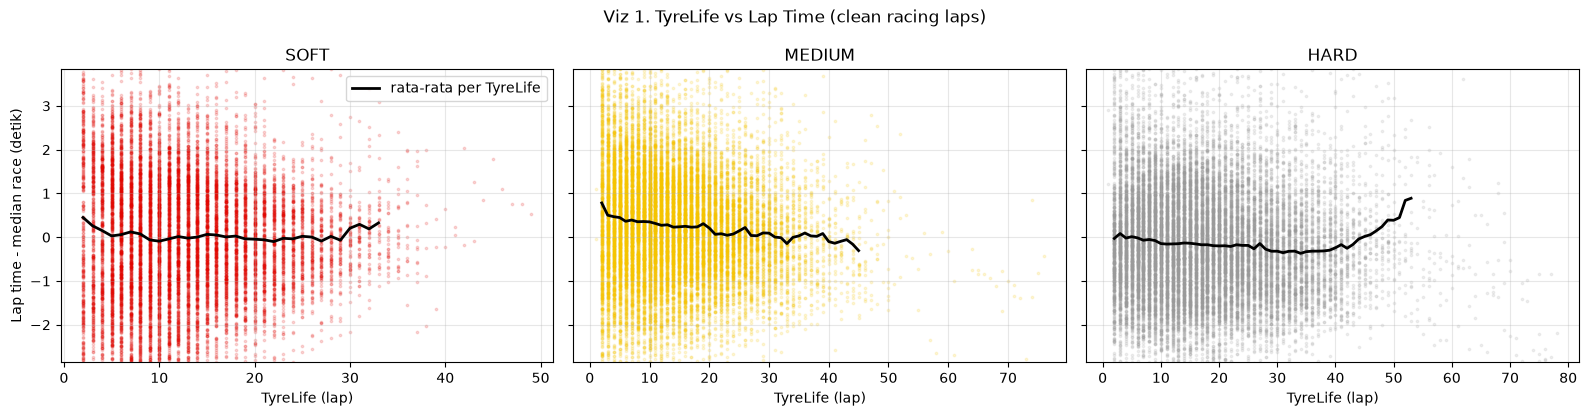

In [7]:
# Viz 1: TyreLife vs pace_delta per compound
lo, hi = clean["pace_delta"].quantile([0.01, 0.99])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, comp in zip(axes, DRY):
    d = clean[clean["Compound"] == comp]
    if d.empty:
        ax.set_title(f"{comp} (tidak ada data)")
        continue
    s = d.sample(min(len(d), 20000), random_state=42)
    ax.scatter(s["TyreLife"], s["pace_delta"], s=3, alpha=0.15, color=COMPOUND_COLORS[comp])
    mean = d.groupby("TyreLife")["pace_delta"].agg(["mean", "count"])
    mean = mean[mean["count"] >= 30]
    ax.plot(mean.index, mean["mean"], color="black", lw=2, label="rata-rata per TyreLife")
    ax.set_title(comp)
    ax.set_xlabel("TyreLife (lap)")
    ax.set_ylim(lo, hi)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Lap time - median race (detik)")
axes[0].legend()
fig.suptitle("Viz 1. TyreLife vs Lap Time (clean racing laps)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/viz1_tyrelife_vs_laptime.png", dpi=150)
plt.show()

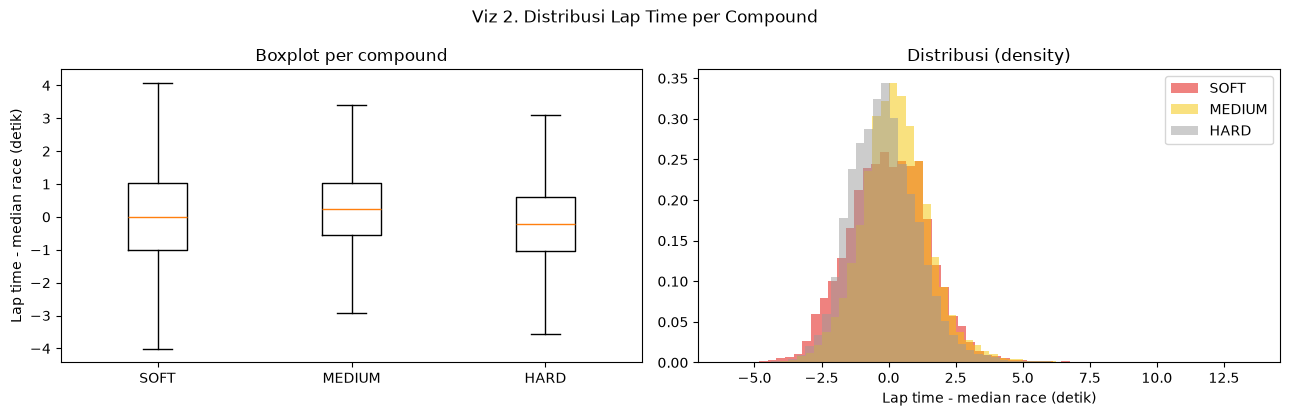

,count,mean,std,min,25%,50%,75%,max
Compound,,,,,,,,
HARD,47785.0,-0.150,1.322,-5.315,-1.049,-0.220,0.617,13.605
MEDIUM,38117.0,0.287,1.368,-5.279,-0.545,0.228,1.035,13.421
SOFT,12378.0,0.036,1.561,-6.114,-1.006,0.010,1.034,13.207


In [8]:
# Viz 2: Distribusi lap time per compound
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
data = [clean.loc[clean["Compound"] == c, "pace_delta"].dropna() for c in DRY]
axes[0].boxplot(data, showfliers=False)
axes[0].set_xticks(range(1, len(DRY) + 1))
axes[0].set_xticklabels(DRY)
axes[0].set_ylabel("Lap time - median race (detik)")
axes[0].set_title("Boxplot per compound")
for c, d in zip(DRY, data):
    axes[1].hist(d, bins=60, alpha=0.5, color=COMPOUND_COLORS[c], label=c, density=True)
axes[1].set_xlabel("Lap time - median race (detik)")
axes[1].set_title("Distribusi (density)")
axes[1].legend()
fig.suptitle("Viz 2. Distribusi Lap Time per Compound")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/viz2_laptime_by_compound.png", dpi=150)
plt.show()
display(clean.groupby("Compound")["pace_delta"].describe().round(3))

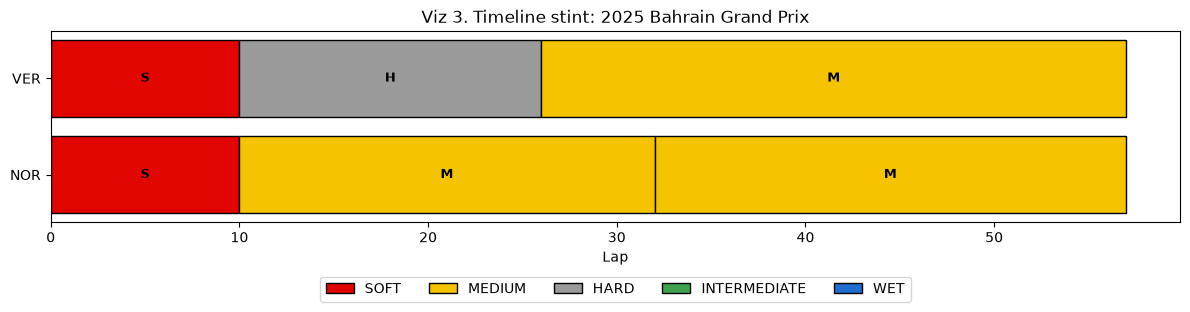

lap_awal  lap_akhir compound
Driver Stint                              
NOR    1.0         1.0       10.0     SOFT
       2.0        11.0       32.0   MEDIUM
       3.0        33.0       57.0   MEDIUM
VER    1.0         1.0       10.0     SOFT
       2.0        11.0       26.0     HARD
       3.0        27.0       57.0   MEDIUM

In [21]:
# Viz 3: Timeline stint / pit strategy (>= 2 pembalap dalam 1 race)
RACE_SEASON = int(df["Season"].max())
RACE_NAME = "Bahrain Grand Prix"      # None = race pertama pada musim tsb; atau isi mis. "Italian Grand Prix"
DRIVERS = ["VER", "NOR"]        # None = 2 finisher terbaik; atau isi mis. ["VER", "NOR"]

race_df = df[df["Season"] == RACE_SEASON]
if RACE_NAME is None:
    RACE_NAME = race_df["RaceName"].iloc[0]
race_df = race_df[race_df["RaceName"] == RACE_NAME]
if DRIVERS is None:
    last = race_df.sort_values("LapNumber").groupby("Driver").tail(1).sort_values("Position")
    DRIVERS = last["Driver"].head(2).tolist()


def stint_compound(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else "UNKNOWN"


fig, ax = plt.subplots(figsize=(12, 1.6 + 0.9 * len(DRIVERS)))
for i, drv in enumerate(DRIVERS):
    d = race_df[race_df["Driver"] == drv]
    for stint, g in d.groupby("Stint"):
        comp = stint_compound(g["Compound"])
        start, end = g["LapNumber"].min(), g["LapNumber"].max()
        ax.barh(i, end - start + 1, left=start - 1, color=COMPOUND_COLORS.get(comp, "#cccccc"),
                edgecolor="black")
        ax.text((start + end) / 2 - 0.5, i, comp[0], ha="center", va="center", fontsize=9, weight="bold")
ax.set_yticks(range(len(DRIVERS)))
ax.set_yticklabels(DRIVERS)
ax.invert_yaxis()
ax.set_xlabel("Lap")
handles = [plt.Rectangle((0, 0), 1, 1, color=COMPOUND_COLORS[c], ec="black") for c in COMPOUND_COLORS]
ax.legend(handles, list(COMPOUND_COLORS), ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.25))
ax.set_title(f"Viz 3. Timeline stint: {RACE_SEASON} {RACE_NAME}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/viz3_stint_timeline.png", dpi=150)
plt.show()

stints = (race_df[race_df["Driver"].isin(DRIVERS)].groupby(["Driver", "Stint"])
          .agg(lap_awal=("LapNumber", "min"), lap_akhir=("LapNumber", "max"),
               compound=("Compound", stint_compound)))
display(stints)

### A.4 Confounder: apakah degradasi ban bisa dibaca langsung?

In [22]:
# Demonstrasi confounder bahan bakar: bandingkan slope TyreLife dengan dan tanpa kontrol 'laps_remaining'.
# laps_remaining tinggi = tangki lebih berat = lebih lambat, sedangkan TyreLife naik seiring lap berjalan.
def ols(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta


rows = []
for comp in DRY:
    d = clean[clean["Compound"] == comp].dropna(subset=["pace_delta", "TyreLife", "laps_remaining"])
    if len(d) < 100:
        continue
    naive = ols(d[["TyreLife"]].to_numpy(), d["pace_delta"].to_numpy())
    ctrl = ols(d[["TyreLife", "laps_remaining"]].to_numpy(), d["pace_delta"].to_numpy())
    rows.append({"Compound": comp, "n": len(d),
                 "slope TyreLife (naif) s/lap": round(naive[1], 4),
                 "slope TyreLife (kontrol bbm) s/lap": round(ctrl[1], 4),
                 "koef laps_remaining s/lap": round(ctrl[2], 4)})
display(pd.DataFrame(rows))

,Compound,n,slope TyreLife (naif) s/lap,slope TyreLife (kontrol bbm) s/lap,koef laps_remaining s/lap
0,SOFT,12378,-0.0057,0.0154,0.0415
1,MEDIUM,38117,-0.0180,0.0086,0.0347
2,HARD,47785,-0.0079,0.0254,0.0496


**Potensi confounder (minimal 3)**

| Confounder | Efek pada pembacaan degradasi | Mitigasi di pemodelan |
|---|---|---|
| **Fuel load menurun** sepanjang race | Mobil makin ringan sehingga lap time membaik, menutupi (menyamarkan) degradasi ban | Sertakan `laps_remaining` / `LapNumber` sebagai fitur |
| **Traffic / dirty air** | Lap lambat karena di belakang mobil lain, bukan karena ban | Fitur posisi / gap (jika tersedia), buang outlier |
| **Safety car / VSC / red flag** | Pace turun drastis; ban "istirahat" dan pit stop murah | Hanya pakai lap green flag; catat sebagai asumsi (SC tidak dimodelkan) |
| **Cuaca & track evolution** | Suhu aspal dan grip berubah sepanjang race dan antar sesi | Fitur `TrackTemp`, `AirTemp`, `Rainfall`; normalisasi `pace_delta` per race |
| **Perbedaan performa mobil / pembalap** | Team cepat terlihat "degradasi lebih kecil" | Fitur `Team` (dengan pemetaan nama antar musim) atau normalisasi per pembalap |
| **Seleksi strategi** | Ban tua hanya muncul pada stint yang memang berjalan bagus (survivorship) | Perlu dibahas di limitation |

**Interpretasi (isi setelah melihat grafik dan tabel di atas)**
1. Apakah degradasi ban terlihat pada Viz 1? Untuk compound mana?
2. Bagaimana slope berubah setelah kontrol bahan bakar?
3. Faktor apa yang paling mengganggu interpretasi pada data kamu?

## Bagian B. Model Lap Time (Simulator Transisi)

Tujuan: `f(state_t, action_t) -> predicted LapTime_(t+1)`, dilatih dari `clean` (hasil Bagian A).

**Fitur yang dipakai (aman / diketahui sebelum lap dijalani):**
`Circuit`, `TeamLineage` (nama team dipetakan lintas rebranding), `Compound`, `TyreLife`,
`Stint`, `LapNumber`, `LapsRemaining` (proksi bahan bakar), `RollingPace3` (rata-rata 3 lap
bersih sebelumnya, dalam race & driver yang sama).

**Fitur yang SENGAJA tidak dipakai (potensi leakage):**
`pace_delta` versi EDA (memakai median seluruh race — informasi masa depan), `Position` setelah
lap (dipengaruhi hasil lap itu sendiri), `Sector*Time` dari lap yang sedang diprediksi.

**Asumsi yang harus disebut di laporan:** `TrackTemp`/`AirTemp` memakai nilai terukur pada lap
tersebut (bukan forecast) — sedikit optimis, tapi lazim di studi motorsport dan hampir tidak
berubah antar lap yang berdekatan.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import joblib

MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

### B.1 Pemetaan nama team lintas musim (rebranding)

In [14]:
# FastF1 memberi nama team sesuai musim; beberapa entitas berganti nama.
# Pemetaan berikut mengelompokkan nama ke 'lineage' agar konsisten sebagai fitur.
# PERIKSA/LENGKAPI sesuai nama persis yang muncul di datamu (lihat daftar di bawah).
TEAM_LINEAGE = {
    "Alfa Romeo Racing": "Sauber_lineage", "Alfa Romeo": "Sauber_lineage",
    "Kick Sauber": "Sauber_lineage", "Sauber": "Sauber_lineage",
    "AlphaTauri": "RB_lineage", "RB": "RB_lineage", "Racing Bulls": "RB_lineage",
    "Racing Point": "Aston_lineage", "Aston Martin": "Aston_lineage",
}


def map_team(s: pd.Series) -> pd.Series:
    return s.map(lambda t: TEAM_LINEAGE.get(t, t))  # default: pakai nama asli bila tidak ada di mapping


print("Nama Team per musim (cek: apakah semua sudah tercakup mapping di atas?)")
display(df.groupby("Season")["Team"].apply(lambda s: sorted(s.dropna().unique())).to_frame("Team"))

Nama Team per musim (cek: apakah semua sudah tercakup mapping di atas?)


,Team
Season,
2021,"[Alfa Romeo Racing, AlphaTauri, Alpine, Aston ..."
2022,"[Alfa Romeo, AlphaTauri, Alpine, Aston Martin,..."
2023,"[Alfa Romeo, AlphaTauri, Alpine, Aston Martin,..."
2024,"[Alpine, Aston Martin, Ferrari, Haas F1 Team, ..."
2025,"[Alpine, Aston Martin, Ferrari, Haas F1 Team, ..."


### B.2 Feature engineering (dari `clean`, hasil Bagian A)

In [15]:
feat = clean.sort_values(["Season", "RaceName", "Driver", "LapNumber"]).copy()
feat["TeamLineage"] = map_team(feat["Team"])
feat["Circuit"] = feat["RaceName"]              # 1 circuit = 1 race dalam dataset ini
feat["LapsRemaining"] = feat["RaceLaps"] - feat["LapNumber"]

# Rolling pace: rata-rata LapTimeSeconds dari lap-lap SEBELUMNYA (shift 1) pada
# race & driver yang sama. shift(1) + rolling mencegah lap saat ini "melihat" dirinya sendiri.
g = feat.groupby(["Season", "RaceName", "Driver"])["LapTimeSeconds"]
feat["RollingPace3"] = g.transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
feat["RollingPace3"] = feat["RollingPace3"].fillna(feat["LapTimeSeconds"].median())  # awal stint

FEATURES_NUM = ["TyreLife", "Stint", "LapNumber", "LapsRemaining", "RollingPace3"]
if "TrackTemp" in feat.columns:
    FEATURES_NUM += ["TrackTemp", "AirTemp"]
FEATURES_CAT = ["Compound", "Circuit", "TeamLineage"]
TARGET = "LapTimeSeconds"

model_df = feat.dropna(subset=FEATURES_NUM + FEATURES_CAT + [TARGET]).copy()
print(f"Baris siap dimodelkan: {len(model_df):,} dari {len(feat):,} clean lap")
model_df[["Season", "RaceName", "Driver"] + FEATURES_NUM + FEATURES_CAT + [TARGET]].head()

Baris siap dimodelkan: 98,280 dari 98,280 clean lap


,Season,RaceName,Driver,TyreLife,Stint,LapNumber,LapsRemaining,RollingPace3,TrackTemp,AirTemp,Compound,Circuit,TeamLineage,LapTimeSeconds
22870,2021,Abu Dhabi Grand Prix,ALO,3.0,1.0,2.0,56.0,85.978500,28.4,24.6,HARD,Abu Dhabi Grand Prix,Alpine,92.422
22871,2021,Abu Dhabi Grand Prix,ALO,4.0,1.0,3.0,55.0,92.422000,28.7,24.6,HARD,Abu Dhabi Grand Prix,Alpine,91.511
22872,2021,Abu Dhabi Grand Prix,ALO,5.0,1.0,4.0,54.0,91.966500,28.4,24.5,HARD,Abu Dhabi Grand Prix,Alpine,91.321
22873,2021,Abu Dhabi Grand Prix,ALO,6.0,1.0,5.0,53.0,91.751333,28.4,24.5,HARD,Abu Dhabi Grand Prix,Alpine,91.339
22874,2021,Abu Dhabi Grand Prix,ALO,7.0,1.0,6.0,52.0,91.390333,28.2,24.5,HARD,Abu Dhabi Grand Prix,Alpine,90.920


### B.3 Split temporal (bukan random split!)

In [16]:
TRAIN_SEASONS = [2021, 2022, 2023]
VAL_SEASONS = [2024]
TEST_SEASONS = [2025]

train = model_df[model_df["Season"].isin(TRAIN_SEASONS)]
val = model_df[model_df["Season"].isin(VAL_SEASONS)]
test = model_df[model_df["Season"].isin(TEST_SEASONS)]

print(f"Train {TRAIN_SEASONS}: {len(train):,} lap, {train.groupby(['Season','RaceName']).ngroups} race")
print(f"Val   {VAL_SEASONS}: {len(val):,} lap, {val.groupby(['Season','RaceName']).ngroups} race")
print(f"Test  {TEST_SEASONS}: {len(test):,} lap, {test.groupby(['Season','RaceName']).ngroups} race")

# Sanity check wajib: pastikan tidak ada race yang sama muncul di lebih dari satu split
overlap = (set(zip(train.Season, train.RaceName)) & set(zip(val.Season, val.RaceName))
           | set(zip(train.Season, train.RaceName)) & set(zip(test.Season, test.RaceName)))
assert not overlap, f"BOCOR! Race berikut ada di >1 split: {overlap}"
print("OK: tidak ada race yang bocor antar split.")

Train [2021, 2022, 2023]: 55,771 lap, 63 race
Val   [2024]: 21,342 lap, 23 race
Test  [2025]: 21,167 lap, 24 race
OK: tidak ada race yang bocor antar split.


### B.4 Baseline: Linear Regression

In [17]:
def to_xy(d):
    return d[FEATURES_NUM + FEATURES_CAT], d[TARGET].to_numpy()


X_train, y_train = to_xy(train)
X_val, y_val = to_xy(val)
X_test, y_test = to_xy(test)

pre = ColumnTransformer([
    ("num", "passthrough", FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])
lin_model = Pipeline([("pre", pre), ("lr", LinearRegression())])
lin_model.fit(X_train, y_train)


def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"{name:35s} MAE={mae:6.3f}s  RMSE={rmse:6.3f}s")
    return mae, rmse


print("--- Linear Regression (baseline) ---")
report("Train", y_train, lin_model.predict(X_train))
report("Val (2024)", y_val, lin_model.predict(X_val))
lr_test_mae, lr_test_rmse = report("Test (2025, unseen)", y_test, lin_model.predict(X_test))

joblib.dump(lin_model, f"{MODEL_DIR}/lap_time_linear.joblib")

--- Linear Regression (baseline) ---
Train                               MAE= 0.826s  RMSE= 1.332s
Val (2024)                          MAE= 1.498s  RMSE= 2.295s
Test (2025, unseen)                 MAE= 1.699s  RMSE= 2.126s


['./models/lap_time_linear.joblib']

### B.5 Model utama: LightGBM

In [18]:
cat_idx = [FEATURES_NUM.__len__() + i for i in range(len(FEATURES_CAT))]  # tidak dipakai; LGBM di bawah pakai kolom category

lgb_train_df = train[FEATURES_NUM + FEATURES_CAT].copy()
lgb_val_df = val[FEATURES_NUM + FEATURES_CAT].copy()
lgb_test_df = test[FEATURES_NUM + FEATURES_CAT].copy()
for c in FEATURES_CAT:
    cats = pd.Categorical(train[c]).categories
    for d in (lgb_train_df, lgb_val_df, lgb_test_df):
        d[c] = pd.Categorical(d[c], categories=cats)

gbm = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.03, num_leaves=31,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=-1,
)
gbm.fit(
    lgb_train_df, y_train,
    eval_set=[(lgb_val_df, y_val)],
    eval_metric="mae",
    categorical_feature=FEATURES_CAT,
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

print(f"--- LightGBM (best_iteration={gbm.best_iteration_}) ---")
report("Train", y_train, gbm.predict(lgb_train_df))
report("Val (2024)", y_val, gbm.predict(lgb_val_df))
gbm_test_mae, gbm_test_rmse = report("Test (2025, unseen)", y_test, gbm.predict(lgb_test_df))

joblib.dump(gbm, f"{MODEL_DIR}/lap_time_lgbm.joblib")

--- LightGBM (best_iteration=181) ---
Train                               MAE= 0.462s  RMSE= 0.734s
Val (2024)                          MAE= 1.097s  RMSE= 2.417s
Test (2025, unseen)                 MAE= 1.325s  RMSE= 2.368s


['./models/lap_time_lgbm.joblib']

### B.6 Ringkasan perbandingan & feature importance

,Model,MAE_test,RMSE_test
0,Linear Regression,1.6988,2.1262
1,LightGBM,1.3255,2.3683


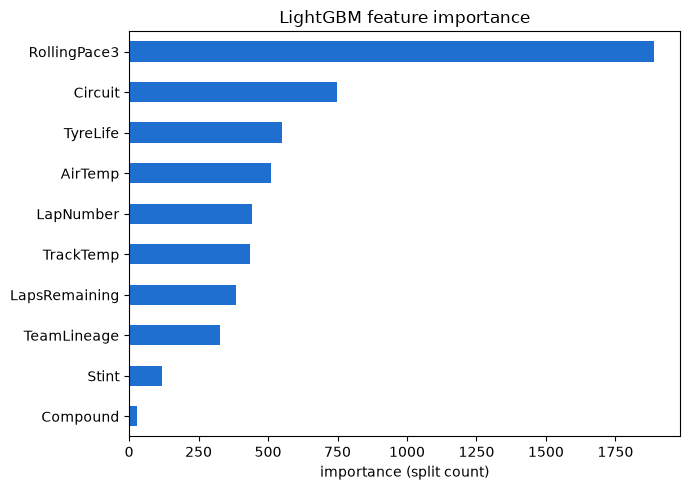

In [19]:
summary = pd.DataFrame([
    {"Model": "Linear Regression", "MAE_test": lr_test_mae, "RMSE_test": lr_test_rmse},
    {"Model": "LightGBM", "MAE_test": gbm_test_mae, "RMSE_test": gbm_test_rmse},
]).round(4)
display(summary)
summary.to_csv(f"{MODEL_DIR}/comparison.csv", index=False)

imp = pd.Series(gbm.feature_importances_, index=FEATURES_NUM + FEATURES_CAT).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax, color="#1f6fd0")
ax.set_title("LightGBM feature importance")
ax.set_xlabel("importance (split count)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/viz4_feature_importance.png", dpi=150)
plt.show()

**Pertanyaan yang harus dijawab di laporan (isi setelah melihat hasil di atas)**
1. Seberapa akurat simulator memprediksi lap time pada season 2025 (unseen)? Bandingkan MAE dengan
   skala variasi lap time itu sendiri (lihat std di Viz 2).
2. Fitur apa yang paling penting menurut LightGBM? Apakah `TyreLife`/`Compound` termasuk yang
   berpengaruh, atau kalah dominan oleh `Circuit`/`RollingPace3`?
3. Apakah LightGBM jauh lebih baik dari Linear Regression? Jika ya, itu indikasi hubungan
   fitur-target memang non-linear (sesuai ekspektasi degradasi ban).
4. Model ini akan dipanggil berulang kali oleh environment RL di Bagian C. Apakah errornya
   (MAE) cukup kecil untuk dipercaya sebagai dasar keputusan pit, atau perlu perbaikan dulu?

## Bagian C: Rancang RL Environment
Di sini kita membuat environment Gymnasium untuk agen RL yang akan mensimulasikan balapan dari awal hingga akhir (episode).

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

class F1StrategyEnv(gym.Env):
    """
    F1 Strategy RL Environment
    State: [LapsRemaining, Compound, TyreLife, Stint, RollingPace3]
    Actions: 
      0: Stay Out
      1: Pit to SOFT
      2: Pit to MEDIUM
      3: Pit to HARD
    """
    
    def __init__(self, predictor_model, race_laps, circuit, team, initial_rolling_pace):
        super(F1StrategyEnv, self).__init__()
        self.predictor_model = predictor_model
        self.race_laps = race_laps
        self.circuit = circuit
        self.team = team
        self.initial_rolling_pace = initial_rolling_pace
        
        # Actions: 4 discrete actions
        self.action_space = spaces.Discrete(4)
        
        # State definition [LapsRemaining, Compound (0,1,2), TyreLife, Stint, RollingPace3]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 1, 60]), 
            high=np.array([100, 2, 100, 10, 150]), 
            dtype=np.float32
        )
        
        self.compounds = ['SOFT', 'MEDIUM', 'HARD']
        self.pit_loss = 22.0  # Asumsi rata-rata time loss untuk pit stop

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.current_lap = 1
        self.laps_remaining = self.race_laps
        self.current_compound_idx = 1 # Start on MEDIUM
        self.tyre_life = 1.0
        self.stint = 1.0
        self.rolling_pace = self.initial_rolling_pace
        
        self.state = np.array([
            self.laps_remaining, 
            self.current_compound_idx, 
            self.tyre_life, 
            self.stint, 
            self.rolling_pace
        ], dtype=np.float32)
        
        return self.state, {}

    def step(self, action):
        pit_time_loss = 0.0
        
        if action == 0: # Stay Out
            self.tyre_life += 1.0
        else: # Pit
            self.current_compound_idx = action - 1 # 1->0 (SOFT), 2->1 (MEDIUM), 3->2 (HARD)
            self.tyre_life = 1.0
            self.stint += 1.0
            pit_time_loss = self.pit_loss
            
        compound_name = self.compounds[self.current_compound_idx]
        
        # Prediksi LapTime menggunakan model Bagian B
        # Feature sesuai yg diharapkan model: [TyreLife, Stint, LapNumber, LapsRemaining, RollingPace3, Compound, Circuit, TeamLineage]
        # (Asumsi cuaca tidak dihitung dulu untuk simplicity, atau masukkan default)
        features = pd.DataFrame([{
            "TyreLife": self.tyre_life,
            "Stint": self.stint,
            "LapNumber": self.current_lap,
            "LapsRemaining": self.laps_remaining,
            "RollingPace3": self.rolling_pace,
            "Compound": compound_name,
            "Circuit": self.circuit,
            "TeamLineage": self.team
        }])
        
        # Pastikan tipe data kategori sesuai
        for col in ["Compound", "Circuit", "TeamLineage"]:
            features[col] = features[col].astype("category")
            
        predicted_lap_time = self.predictor_model.predict(features)[0]
        
        # Update rolling pace
        self.rolling_pace = (self.rolling_pace * 2 + predicted_lap_time) / 3.0
        
        self.current_lap += 1
        self.laps_remaining -= 1
        
        # Reward: negatif dari total waktu yang dihabiskan di lap tersebut
        reward = -(predicted_lap_time + pit_time_loss)
        
        terminated = bool(self.laps_remaining <= 0)
        truncated = False
        
        self.state = np.array([
            self.laps_remaining, 
            self.current_compound_idx, 
            self.tyre_life, 
            self.stint, 
            self.rolling_pace
        ], dtype=np.float32)
        
        info = {
            "predicted_lap_time": predicted_lap_time,
            "pit_time_loss": pit_time_loss
        }
        
        return self.state, reward, terminated, truncated, info

# Contoh inisialisasi environment:
# env = F1StrategyEnv(predictor_model=gbm, race_laps=50, circuit="Abu Dhabi Grand Prix", team="Mercedes", initial_rolling_pace=90.0)
